In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [31]:
data = pd.read_csv("../00_Productive_Data/charging_data_clean.csv")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        60922 non-null  int64  
 1   id                60922 non-null  object 
 2   connectionTime    60922 non-null  object 
 3   disconnectTime    60922 non-null  object 
 4   doneChargingTime  60922 non-null  object 
 5   kWhDelivered      60922 non-null  float64
 6   sessionID         60922 non-null  object 
 7   siteID            60922 non-null  int64  
 8   spaceID           60922 non-null  object 
 9   timezone          60922 non-null  object 
 10  userID            44637 non-null  float64
 11  userInputs        44637 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.6+ MB


## Data Preparation for clustering

First we want to drop all the features in our dataset which are of no relevance for our clustering. Furthermore we drop all datapoints of unregistered user, since we are going to analyse the behavior of registered users.

In [32]:
data_reg = data.drop(["Unnamed: 0", "id"], axis=1)
data_reg = data_reg.dropna(subset=["userID"])


In [33]:
date_columns = ["connectionTime", "disconnectTime", "doneChargingTime"]

for data in date_columns:
    data_reg[data] = pd.to_datetime(data_reg[data])

def convert_to_local(row): 
    tz = row["timezone"]
    for col in date_columns:
        ts = row[col]
        if pd.isna(ts):
            continue 
        row[col] = ts.tz_convert(tz)
    return row 

data_reg = data_reg.apply(convert_to_local, axis=1)

data_reg.info()

C:\Users\Larissa\AppData\Local\Temp\ipykernel_5160\139336585.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_reg[data] = pd.to_datetime(data_reg[data])
C:\Users\Larissa\AppData\Local\Temp\ipykernel_5160\139336585.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_reg[data] = pd.to_datetime(data_reg[data])
C:\Users\Larissa\AppData\Local\Temp\ipykernel_5160\139336585.py:4: FutureWarning: In a future version of pandas, parsing datet

<class 'pandas.core.frame.DataFrame'>
Index: 44637 entries, 2 to 60921
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   connectionTime    44637 non-null  datetime64[ns, America/Los_Angeles]
 1   disconnectTime    44637 non-null  datetime64[ns, America/Los_Angeles]
 2   doneChargingTime  44637 non-null  datetime64[ns, America/Los_Angeles]
 3   kWhDelivered      44637 non-null  float64                            
 4   sessionID         44637 non-null  object                             
 5   siteID            44637 non-null  int64                              
 6   spaceID           44637 non-null  object                             
 7   timezone          44637 non-null  object                             
 8   userID            44637 non-null  float64                            
 9   userInputs        44637 non-null  object                          

## Preparing relevant features

In order to describe user behavior, we want to analyse the time of connection and the duration. 
- **charging duration**: We calculate the duration of charging from the features "doneChargingTime" and "connectionTime".
- **blocking duration**: We look at the duration when the car is done charging and still connected to the station, as it shows typical user behavior.
- **connection hour**: We extract the hour of the day from the variable "connectionTime". Since the hour of connection is cyclical, we cannot use it as an integer when we cluster. The hours 23 and 00 have a very large distance (23), eventhough they are very close. That is why we represent the time of connection by two variables hour_sin and hour_cos.
- **weekday**: We extract the day of the week from the variable "connectionTime" and devide the days of the week into two categories (weekday and weekend). We can drop the second category, since it is implicity defined by the first one.

In [34]:
data_reg["blocking_duration_min"] = ((data_reg["disconnectTime"] - data_reg["doneChargingTime"]).dt.total_seconds()/60).round()
data_reg["charging_duration_min"] = ((data_reg["doneChargingTime"] - data_reg["connectionTime"]).dt.total_seconds()/60).round()

data_reg["connection_hour"] = data_reg["connectionTime"].dt.hour
data_reg["con_hour_sin"] = np.sin(2 * np.pi * data_reg["connection_hour"] / 24)
data_reg["con_hour_cos"] = np.cos(2 * np.pi * data_reg["connection_hour"] / 24)

data_reg["weekday"] = data_reg["connectionTime"].dt.dayofweek
data_reg["is_weekday"] = data_reg["weekday"] < 5


We convert the feature "siteID" into a boolean feature for siteID = 1. As before, we do not need a second feature for siteID = 2, as it is implicity described by the first feature.

In [35]:
data_reg["siteOne"] = (data_reg["siteID"] == 1)

 ### Handling of the User Inputs

We convert our userInputs and delete all rows where the userInputs have multiple lists.

In [36]:
import ast
data_reg['userInputs'] = data_reg['userInputs'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [37]:
data_reg["userInputs"] = data_reg["userInputs"].apply(
    lambda x: x[:1] if isinstance(x, list) and len(x) > 1 else x
)

In [9]:
#pd.set_option("display.max_colwidth", None)

Payment Required always true, so unimportant

In [38]:
data_reg['userInputs'] = data_reg['userInputs'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) == 1 else {}
)

keys = [
    'WhPerMile',
    'kWhRequested',
    'minutesAvailable',
    'milesRequested'
]

for k in keys:
    data_reg[k] = data_reg['userInputs'].apply(lambda d: d.get(k))

data_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44637 entries, 2 to 60921
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype                              
---  ------                 --------------  -----                              
 0   connectionTime         44637 non-null  datetime64[ns, America/Los_Angeles]
 1   disconnectTime         44637 non-null  datetime64[ns, America/Los_Angeles]
 2   doneChargingTime       44637 non-null  datetime64[ns, America/Los_Angeles]
 3   kWhDelivered           44637 non-null  float64                            
 4   sessionID              44637 non-null  object                             
 5   siteID                 44637 non-null  int64                              
 6   spaceID                44637 non-null  object                             
 7   timezone               44637 non-null  object                             
 8   userID                 44637 non-null  float64                            
 9   userInputs 

### Handling outliers

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

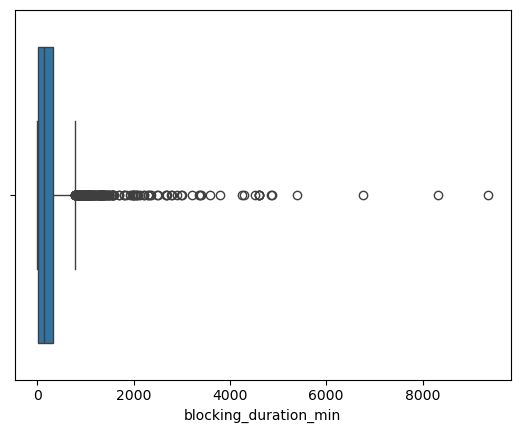

In [40]:
sns.boxplot(x=data_reg["blocking_duration_min"])
plt.show()

In [42]:
def iqr_outliers(series, lower_k, upper_k):
    Q1 = series.quantile(0.15)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - lower_k * IQR
    upper = Q3 + upper_k * IQR
    return lower, upper

lowerkWh, upperkWh = iqr_outliers(
    data_reg["kWhDelivered"], 
    lower_k=1.5, upper_k=5.0
    )

lowerc, upperc = iqr_outliers(
    data_reg["charging_duration_min"], 
    lower_k=1.5, upper_k=6.0
    )

lowerb, upperb = iqr_outliers(
    data_reg["blocking_duration_min"], 
    lower_k=1.5, upper_k=8.0
    )

data_reg = data_reg[
    (data_reg["kWhDelivered"] >= lowerkWh) &
    (data_reg["kWhDelivered"] <= upperkWh) &
    (data_reg["charging_duration_min"] >= lowerc) &
    (data_reg["charging_duration_min"] <= upperc) &
    (data_reg["blocking_duration_min"] >= lowerb) &
    (data_reg["blocking_duration_min"] <= upperb)
]
#sns.boxplot(x=data_reg["blocking_duration_min"])
#plt.show()

data_reg.info()


<class 'pandas.core.frame.DataFrame'>
Index: 44594 entries, 2 to 60921
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype                              
---  ------                 --------------  -----                              
 0   connectionTime         44594 non-null  datetime64[ns, America/Los_Angeles]
 1   disconnectTime         44594 non-null  datetime64[ns, America/Los_Angeles]
 2   doneChargingTime       44594 non-null  datetime64[ns, America/Los_Angeles]
 3   kWhDelivered           44594 non-null  float64                            
 4   sessionID              44594 non-null  object                             
 5   siteID                 44594 non-null  int64                              
 6   spaceID                44594 non-null  object                             
 7   timezone               44594 non-null  object                             
 8   userID                 44594 non-null  float64                            
 9   userInputs 

In [43]:
data_reg["kWhrequest_difference"] = data_reg["kWhRequested"] - data_reg["kWhDelivered"]
data_reg["kWhrequest_ratio"] = data_reg["kWhDelivered"]/(data_reg["kWhRequested"]+1)
print(data_reg["kWhrequest_difference"].min())
print(data_reg["kWhrequest_difference"].max())

-46.281
213.686


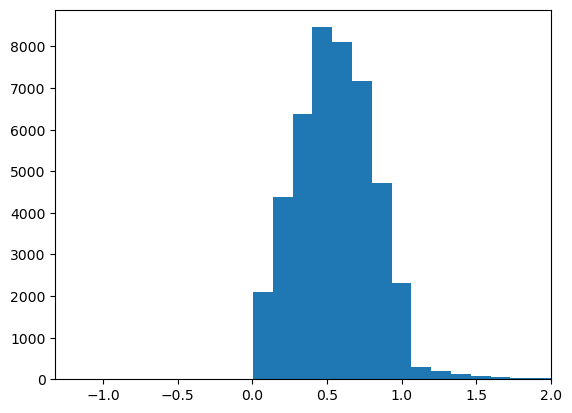

In [44]:
plt.hist(data_reg["kWhrequest_ratio"], bins=200)
plt.xlim(right=2)
plt.show()

## Create User Dataframe


In [45]:
user_df = (
    data_reg
    .groupby("userID")
    .agg(
        n_sessions=("sessionID", "count"),

        first_session=("connectionTime", "min"),
        last_session=("connectionTime", "max"),
        
        avg_charging_time=("charging_duration_min", "mean"),
        avg_blocking_time=("blocking_duration_min", "mean"),
        weekday_ratio=("is_weekday", "mean"),
        
        avg_kWh=("kWhDelivered", "mean"),
        
        site_one_ratio=("siteOne", "mean"),

        avg_connection_hour_sin=("con_hour_sin", "mean"),
        avg_connection_hour_cos=("con_hour_cos", "mean"),
        
        avg_wh_per_mile=("WhPerMile", "mean"),
        avg_minutes_available=("minutesAvailable", "mean"),
        avg_kWh_requested=("kWhRequested", "mean")
    )
    .reset_index()
)

In [46]:
observation_start = data_reg['connectionTime'].min()
observation_end = data_reg["connectionTime"].max()
observation_span_weeks = (observation_end - observation_start).total_seconds()/(60*60*24*7)

user_df["active_weeks"] = (user_df["last_session"]-user_df["first_session"]).dt.total_seconds()/(60*60*24*7) + 1
user_df["active_weeks_ratio"] = user_df["active_weeks"] / observation_span_weeks
user_df["sessions_per_week"] = user_df["n_sessions"] / user_df["active_weeks"]

print(observation_start)
print(observation_end)
print(observation_span_weeks)

user_df["is_single_user"] = user_df["n_sessions"] == 1
user_df.head(5)

2018-04-30 08:07:49-07:00
2021-09-13 22:43:39-07:00
176.0868882275132


,userID,n_sessions,first_session,last_session,avg_charging_time,avg_blocking_time,weekday_ratio,avg_kWh,site_one_ratio,avg_connection_hour_sin,avg_connection_hour_cos,avg_wh_per_mile,avg_minutes_available,avg_kWh_requested,active_weeks,active_weeks_ratio,sessions_per_week,is_single_user
0,1.0,1,2018-06-22 13:11:23-07:00,2018-06-22 13:11:23-07:00,74.000000,10.000000,1.0,1.659000,0.0,-0.258819,-0.965926,500.000000,150.000000,5.000000,1.000000,0.005679,1.000000,True
1,17.0,1,2018-11-25 15:40:28-08:00,2018-11-25 15:40:28-08:00,18.000000,0.000000,0.0,1.471000,0.0,-0.707107,-0.707107,346.000000,30.000000,6.920000,1.000000,0.005679,1.000000,True
2,22.0,57,2018-04-30 08:07:49-07:00,2020-01-13 12:51:37-08:00,257.052632,129.947368,1.0,18.748033,0.0,0.579329,-0.636510,352.631579,461.578947,35.955263,90.034107,0.511305,0.633093,False
3,43.0,1,2018-08-11 09:12:38-07:00,2018-08-11 09:12:38-07:00,419.000000,78.000000,0.0,43.266000,0.0,0.707107,-0.707107,217.000000,469.000000,43.400000,1.000000,0.005679,1.000000,True
4,45.0,1,2018-09-16 17:00:47-07:00,2018-09-16 17:00:47-07:00,129.000000,84.000000,0.0,8.069000,0.0,-0.965926,-0.258819,250.000000,134.000000,17.500000,1.000000,0.005679,1.000000,True


## Analyse correlations

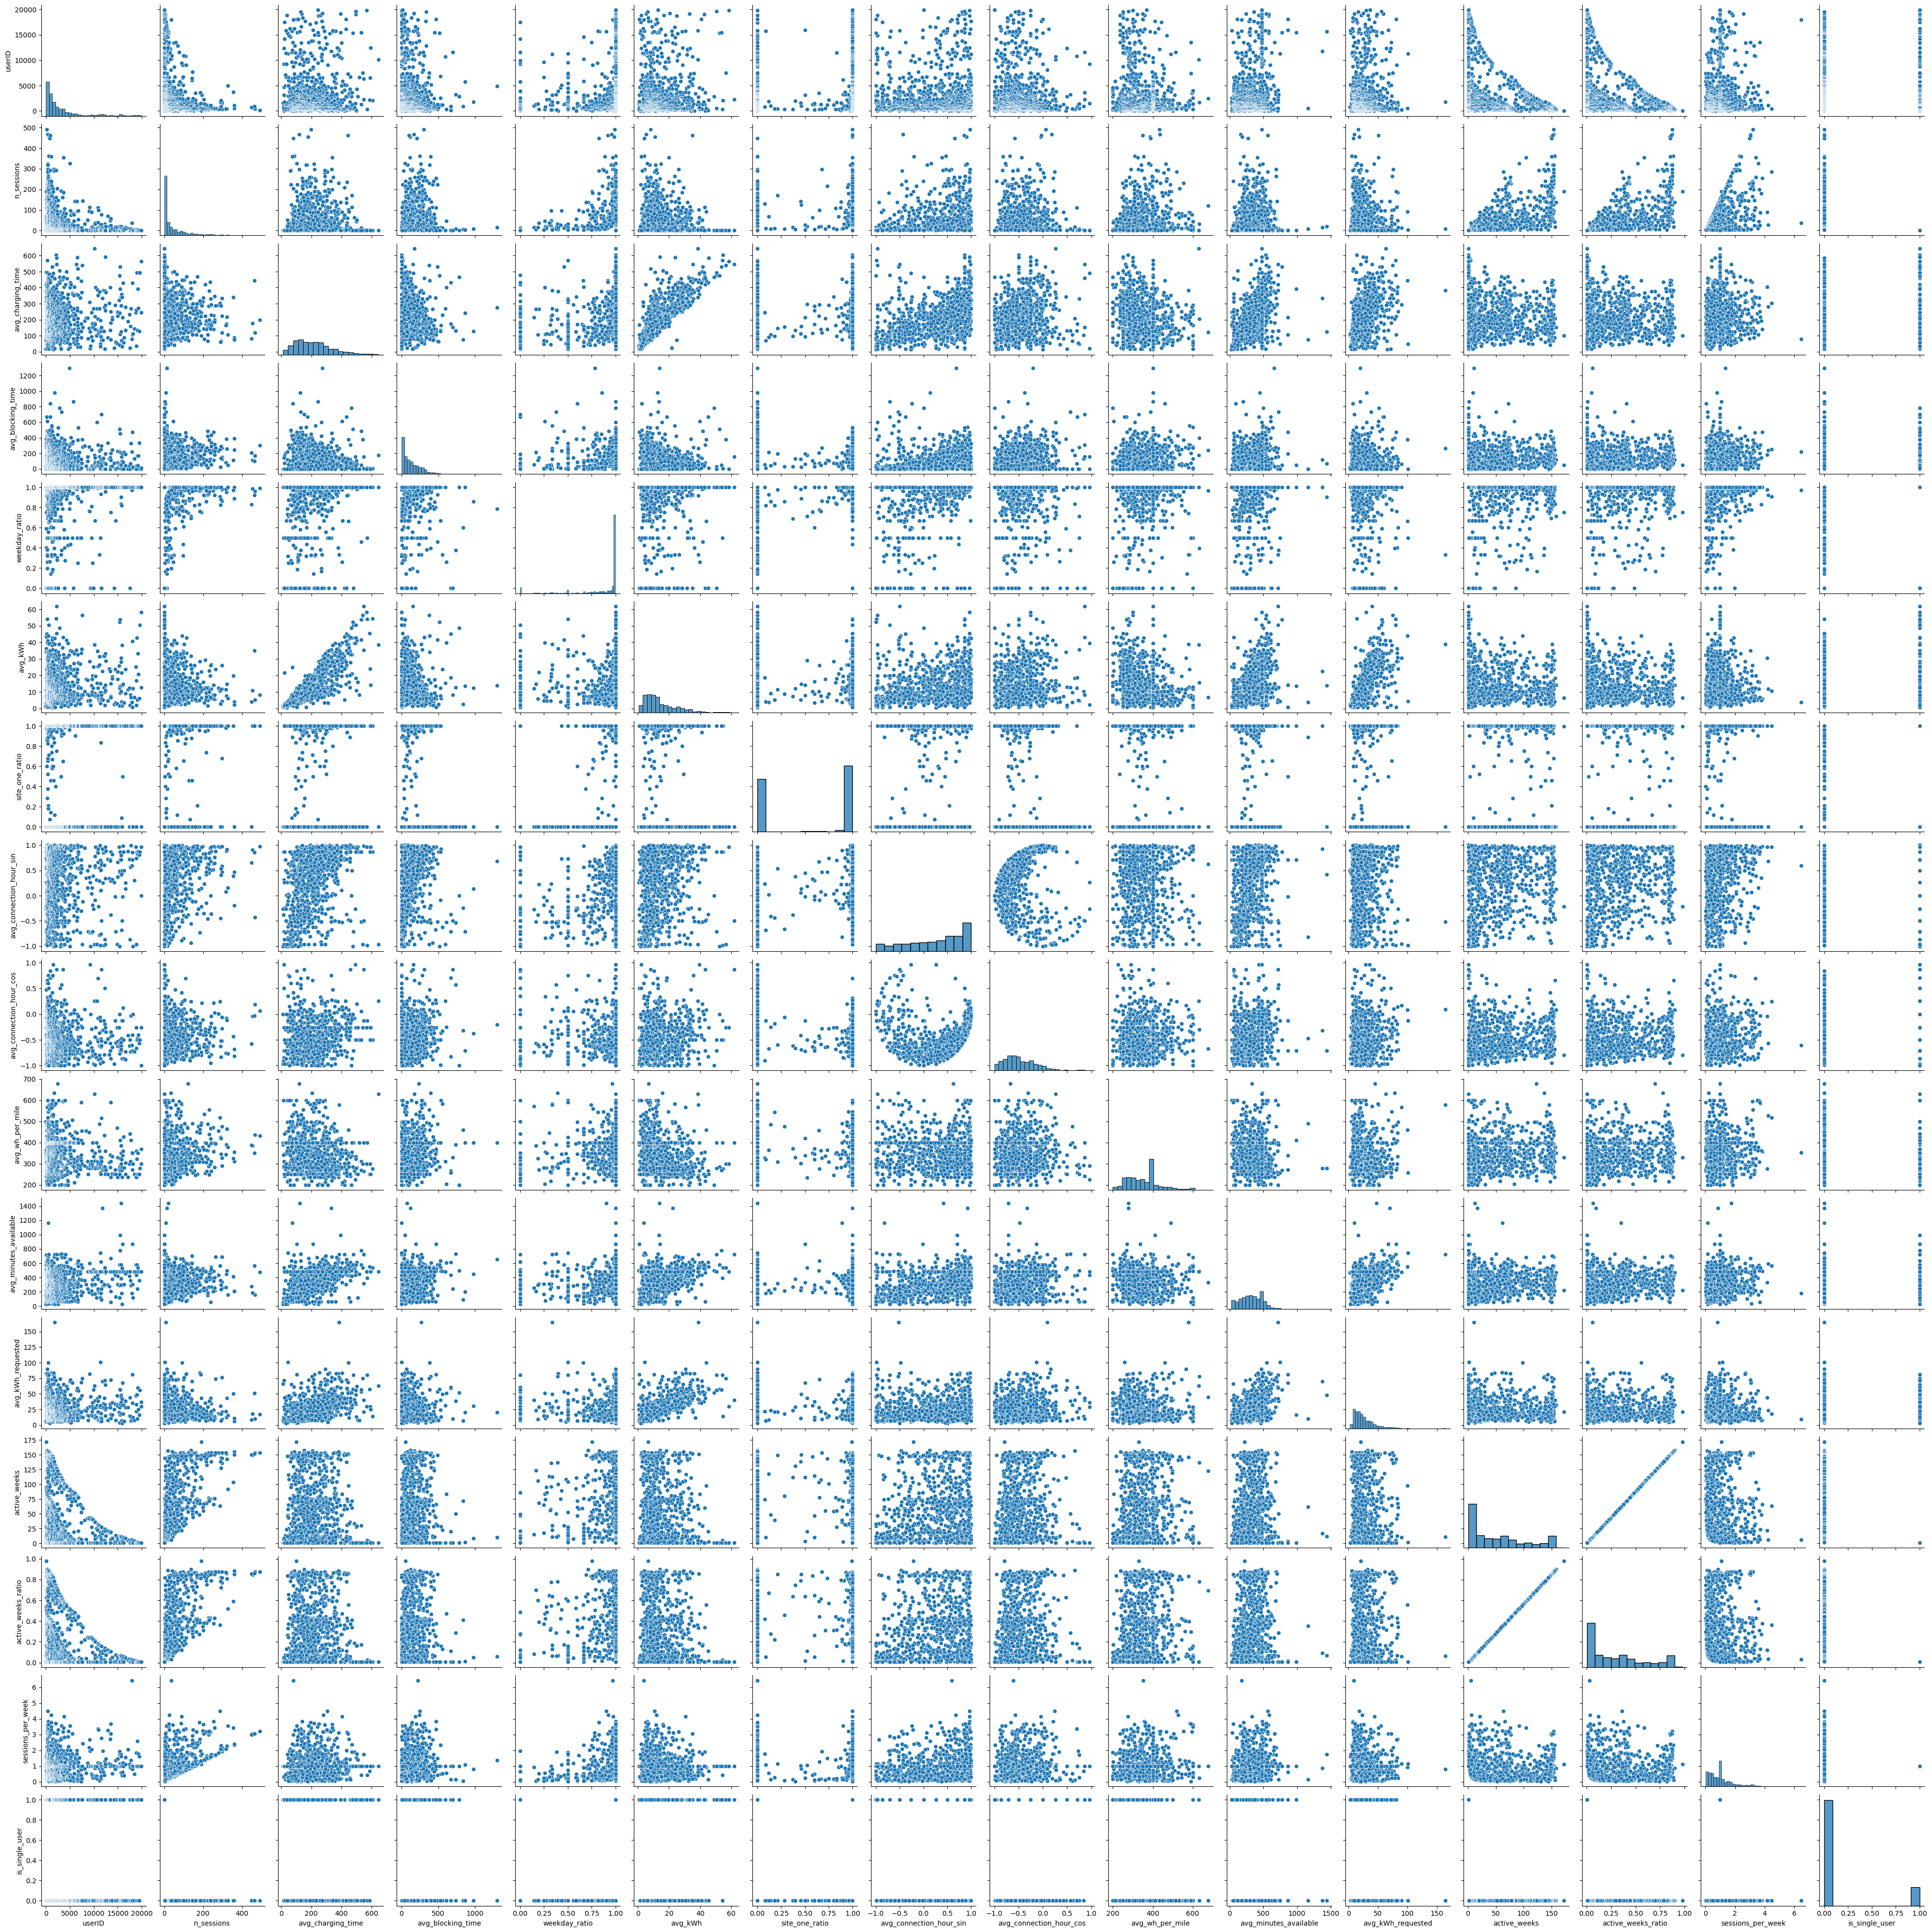

In [47]:
sns.pairplot(user_df)
plt.show()

In [48]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from skfda.ml.clustering import FuzzyCMeans
from matplotlib.lines import Line2D
from sklearn.metrics import silhouette_samples, silhouette_score
%matplotlib inline

### Dropping irrelevant or less relevant features

To avaid the curse of dimensinality, we want to keep only the most valuable features. Firstly we can drop "userID", "n_sessions", "first_session", "last_session" and "active_weeks". We look at the correlations between features, their distributions and their logical significance, to determine which features to keep.

In [73]:
# dropping avg wh per mile and avg kWh, because it doesnt seem to have any relevance
X = user_df.drop(["userID","n_sessions","first_session", "last_session", "active_weeks", "avg_wh_per_mile", "avg_minutes_available", "avg_kWh", "avg_kWh_requested", "active_weeks_ratio"], axis=1)
X

,avg_charging_time,avg_blocking_time,weekday_ratio,site_one_ratio,avg_connection_hour_sin,avg_connection_hour_cos,sessions_per_week,is_single_user
0,74.000000,10.000000,1.0,0.0,-2.588190e-01,-0.965926,1.000000,True
1,18.000000,0.000000,0.0,0.0,-7.071068e-01,-0.707107,1.000000,True
2,257.052632,129.947368,1.0,0.0,5.793294e-01,-0.636510,0.633093,False
3,419.000000,78.000000,0.0,0.0,7.071068e-01,-0.707107,1.000000,True
4,129.000000,84.000000,0.0,0.0,-9.659258e-01,-0.258819,1.000000,True
...,...,...,...,...,...,...,...,...
883,272.333333,168.666667,1.0,1.0,8.796528e-01,-0.408248,1.763262,False
884,129.000000,332.000000,1.0,1.0,8.130525e-01,-0.569036,1.620210,False
885,494.000000,0.000000,1.0,1.0,8.660254e-01,-0.500000,1.000000,True
886,565.000000,0.000000,1.0,0.0,9.659258e-01,-0.258819,1.000000,True


### Scaling

In [74]:
#Skalierung mit RobustScaler, da Ausreißer vorhanden sind und so robuster
use_robust = True
if (use_robust):
    scaler = RobustScaler()
else: scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Clustering

### K-Means CLustering

In [75]:
kclusters = []
klabels = pd.DataFrame()
ksil_scores = []
klosses = []

for k in range(2, 20):
    cluster = str(k)
    kclusters.append(k)
    kmodel = KMeans(n_clusters=k, random_state=42)
    label = kmodel.fit_predict(X_scaled)
    klabels[cluster] = label
    ksil_scores.append(silhouette_score(X_scaled, klabels[cluster]))
    klosses.append(kmodel.inertia_)

c:\Users\Larissa\anaconda3\envs\AA_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Larissa\anaconda3\envs\AA_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Larissa\anaconda3\envs\AA_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Larissa\anaconda3\envs\AA_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

Text(0.5, 1.0, ' ksilhouette score - Robustscaler True')

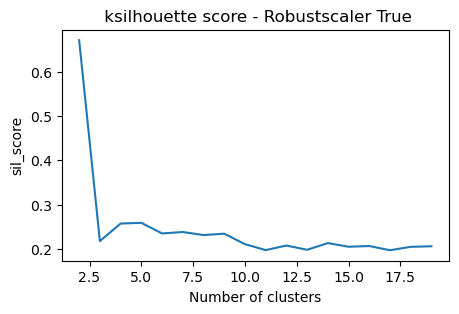

In [76]:
plt.figure(figsize=(5,3))
plt.plot(kclusters, ksil_scores)
plt.ylabel("sil_score")
plt.xlabel("Number of clusters")
plt.title(f" ksilhouette score - Robustscaler {use_robust}")

Text(0.5, 0, 'Number of clusters')

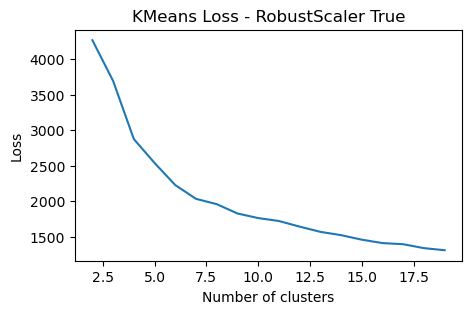

In [77]:
plt.figure(figsize=(5,3))
plt.plot(kclusters, klosses)
plt.ylabel("Loss")
plt.title(f"KMeans Loss - RobustScaler {use_robust}")
plt.xlabel("Number of clusters")

In [78]:
aclusters = []
alabels = pd.DataFrame()
asil_scores = []
alosses = []

for k in range(2, 20):
    cluster = str(k)
    aclusters.append(k)
    amodel = AgglomerativeClustering(n_clusters=k)
    label = amodel.fit_predict(X_scaled)
    alabels[cluster] = label
    asil_scores.append(silhouette_score(X_scaled, label))

Text(0.5, 1.0, 'asilhouette score - RobustScaler True')

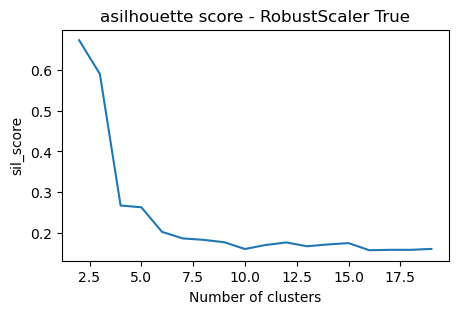

In [79]:
plt.figure(figsize=(5,3))
plt.plot(aclusters, asil_scores)
plt.ylabel("sil_score")
plt.xlabel("Number of clusters")
plt.title(f"asilhouette score - RobustScaler {use_robust}")

In [80]:
#cluster 5 oder 7
kbest_cluster = str(7)
X["labels"] = klabels[kbest_cluster]
X

,avg_charging_time,avg_blocking_time,weekday_ratio,site_one_ratio,avg_connection_hour_sin,avg_connection_hour_cos,sessions_per_week,is_single_user,labels
0,74.000000,10.000000,1.0,0.0,-2.588190e-01,-0.965926,1.000000,True,3
1,18.000000,0.000000,0.0,0.0,-7.071068e-01,-0.707107,1.000000,True,1
2,257.052632,129.947368,1.0,0.0,5.793294e-01,-0.636510,0.633093,False,3
3,419.000000,78.000000,0.0,0.0,7.071068e-01,-0.707107,1.000000,True,1
4,129.000000,84.000000,0.0,0.0,-9.659258e-01,-0.258819,1.000000,True,1
...,...,...,...,...,...,...,...,...,...
883,272.333333,168.666667,1.0,1.0,8.796528e-01,-0.408248,1.763262,False,6
884,129.000000,332.000000,1.0,1.0,8.130525e-01,-0.569036,1.620210,False,6
885,494.000000,0.000000,1.0,1.0,8.660254e-01,-0.500000,1.000000,True,5
886,565.000000,0.000000,1.0,0.0,9.659258e-01,-0.258819,1.000000,True,5


In [81]:
def sincos_to_hour(sin_val, cos_val):
    angle = np.arctan2(sin_val, cos_val)
    hour = (angle * 24 / (2 * np.pi)) % 24
    return hour

X["avg_connection_hour"] = sincos_to_hour(X["avg_connection_hour_sin"], X["avg_connection_hour_cos"])
X = X.drop(["avg_connection_hour_sin", "avg_connection_hour_cos"], axis=1)

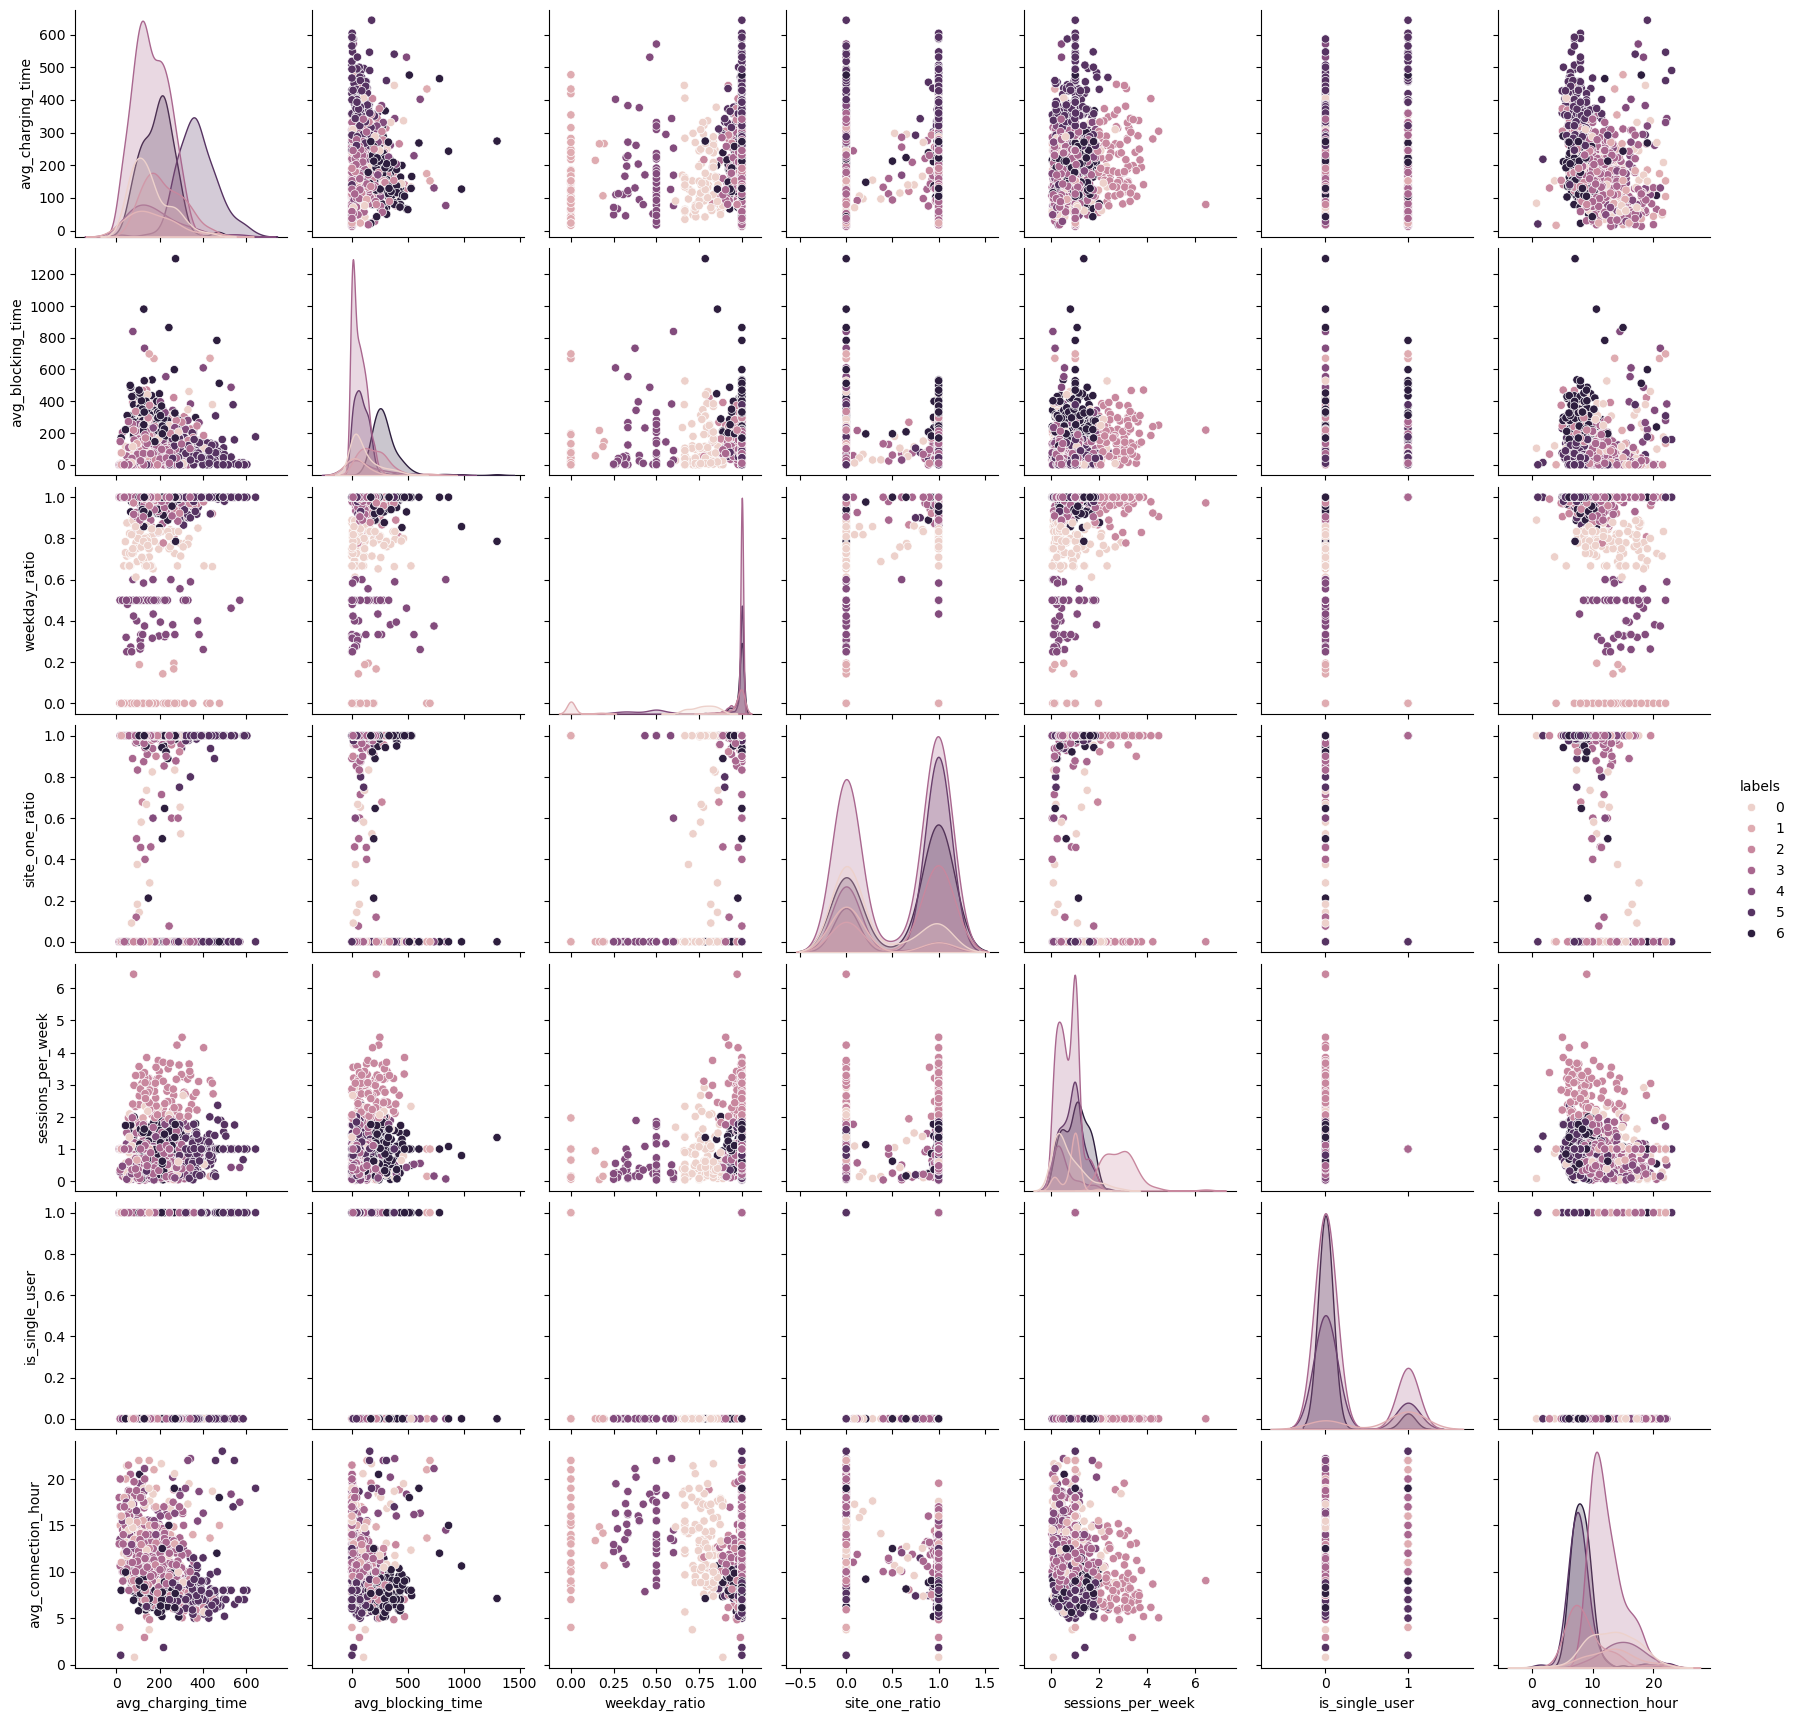

In [82]:
sns.pairplot(X, hue="labels")
plt.show()

In [ ]:
#X[X["labels"] == 0].describe()

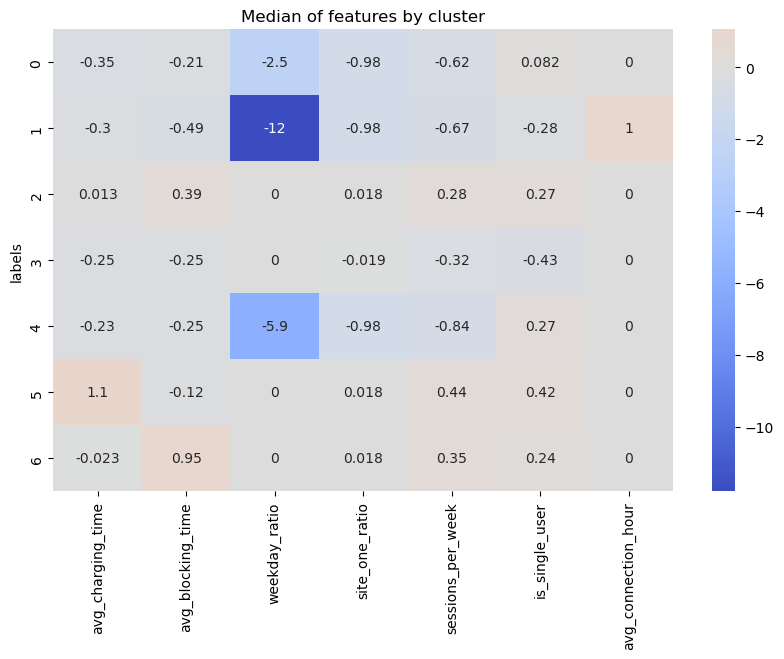

In [83]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,   # wichtig!
    index=X.index
)

X_scaled_df["labels"] = X["labels"]
features = X_scaled_df.columns.drop("labels")
cluster_medians = X_scaled_df.groupby("labels")[features].median()

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_medians,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Median of features by cluster")
plt.show()

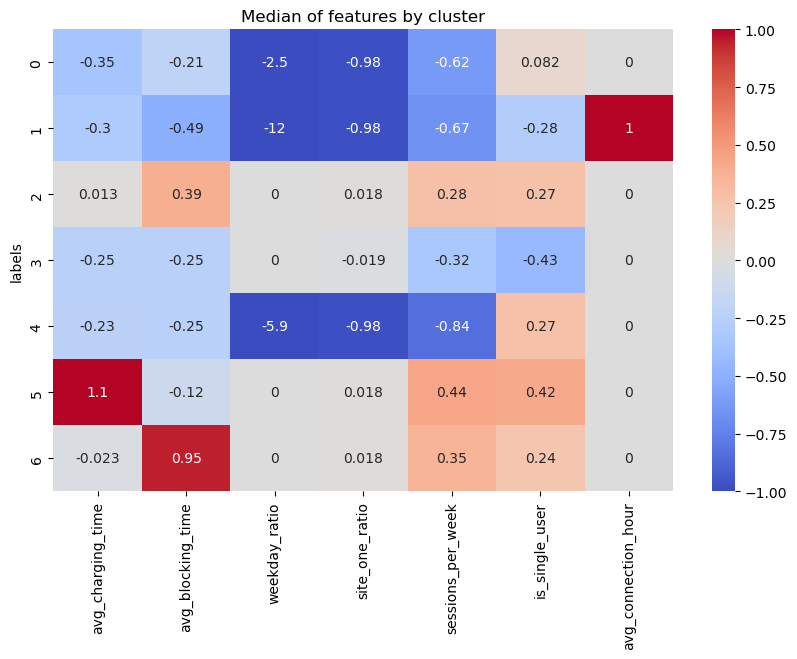

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_medians,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Median of features by cluster")
plt.show()

Agglomerative with 7 clusters:
- Cluster 0: charge very regularly and quik, efficient, early in the day - pendler, ideal user for infrastructure
- Cluster 1: charge mid often and a little longer, have the time and charge later the day - regular user who have chargingstation 1 close to the workplace or home, potentially blocking but planbar
- Cluster 2: all values relatively close to zero, charges at station 1 - average user with no strong pattern, good as reference group
- Cluster 3: average user who charges at station 2, has a little more time than cluster 2 users
- cluster 4: irregular weekend user who charge later of the day and have very long charging and blocking time - inefficient blockers, problematic, hard to calculate
- cluster 5: users who charge only on the weekwend, who are efficient and charge quickly
- cluster 6: user with short charging times who leave right after charging and charge irregulary - hobby driver, little routine



In [61]:
X["labels"].value_counts().sort_index()

labels
0    102
1    114
2    129
3    182
4     29
5     37
6     68
7     73
8    154
Name: count, dtype: int64

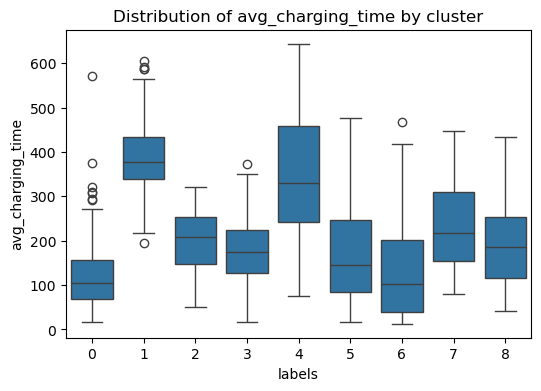

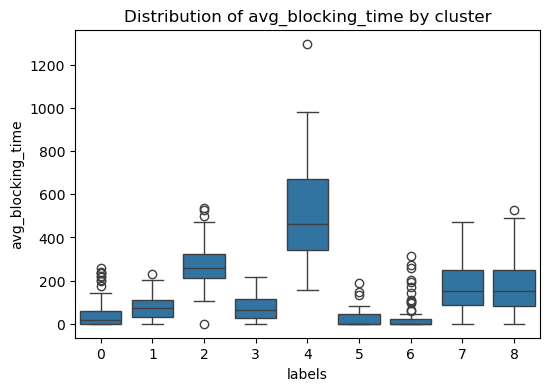

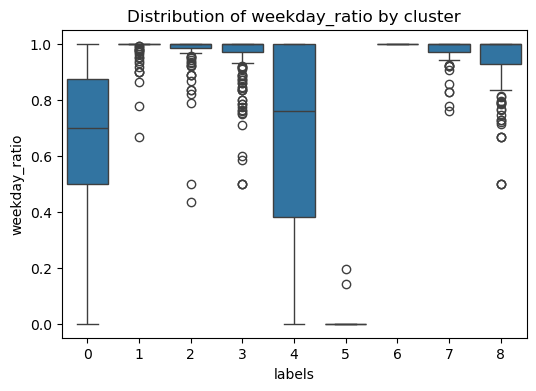

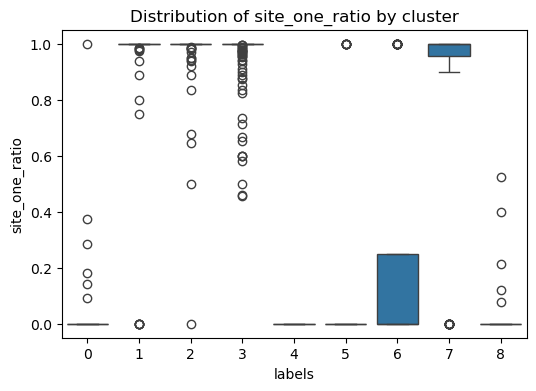

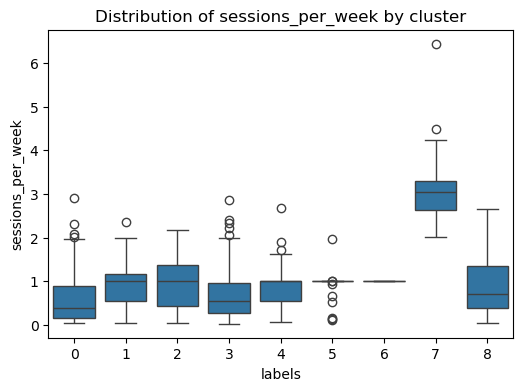

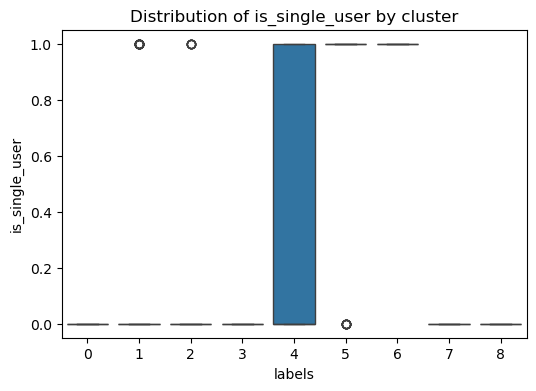

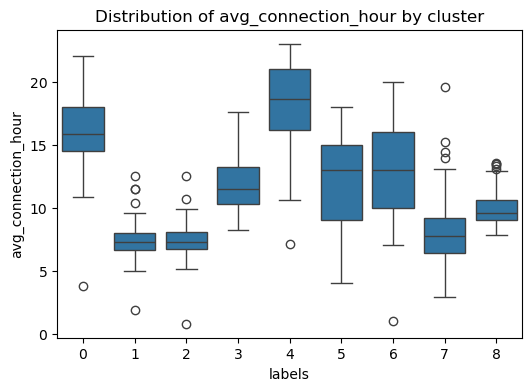

In [62]:
for f in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="labels", y=f, data=X)
    plt.title(f"Distribution of {f} by cluster")
    plt.show()